# Geospatial Analysis of Public Health Facilities

In [ ]:
# this script analyzes the demo_health_facilities_geo_data_NHC.csv dataset
# this is a demo geolocation dataset storing geospatial information...
# ... from an hypothetical group of public health facilities
# the dataset has 767 observations and 3 fields

In [1]:
# before importing any library, run the statements below in the terminal
# when installing any package, make sure to be in the proper environment!
# conda install anaconda::pandas
# conda install conda-forge::matplotlib
# conda install conda-forge::geopandas

import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
import folium
from folium.plugins import HeatMap
from folium.plugins import MarkerCluster

In [ ]:
# assign the path to the input and output file folders to a variable for reproducibility (and privacy)
input_folder_path = "path/to/input/file/folder/"
output_folder_path = "path/to/output/file/folder/"

## 01: Explore the Dataset Pt. 1

In [3]:
# read a CSV into a data frame
df_geo = pd.read_csv(input_folder_path+"demo_health_facilities_geo_data_NHC.csv")
df_geo

,Facility Type,Latitude,Longitude
0,Hospital,5.593051,3.697007
1,Hospital,10.017569,9.921846
2,Hospital,7.568808,11.178651
3,Hospital,11.574567,12.594135
4,Hospital,6.093634,9.334975
...,...,...,...
762,Pharmacy,11.844224,9.831699
763,Pharmacy,8.228317,8.502529
764,Pharmacy,8.162100,4.821424
765,Pharmacy,7.568452,8.388384


In [4]:
# count unique 'Facility Type' values
facility_type_count = df_geo["Facility Type"].value_counts()
facility_type_count

Facility Type
Pharmacy                         627
Primary Care Center              118
Specialized Healthcare Center     12
Hospital                          10
Name: count, dtype: int64

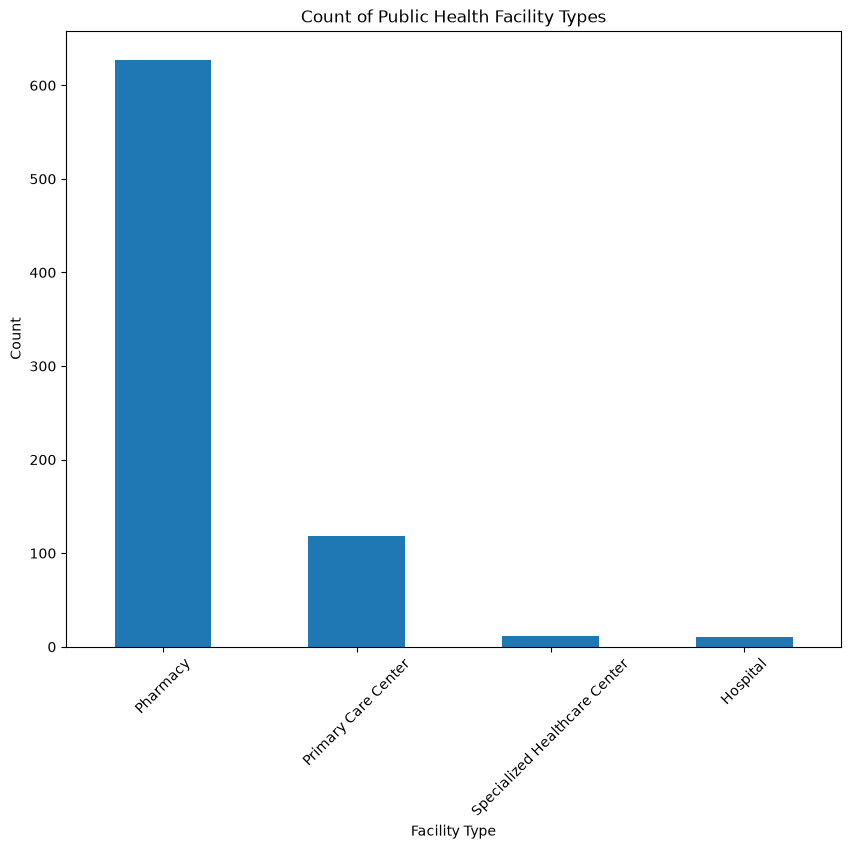

In [5]:
# visualize the count of unique 'Facility Type' values as a bar chart
plt.figure(figsize=(10, 8))
facility_type_count.plot(kind="bar")
plt.title("Count of Public Health Facility Types")
plt.xlabel("Facility Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

In [ ]:
# create a GeoDataFrame object i.e., derive geo(metry) points for each data instance
# a GeoDataFrame object is a pandas.DataFrame that has one or more columns containing geometry
gdf = gpd.GeoDataFrame(df_geo, geometry=gpd.points_from_xy(df_geo.Longitude, df_geo.Latitude))
gdf

,Facility Type,Latitude,Longitude,geometry
0,Hospital,5.593051,3.697007,POINT (3.69701 5.59305)
1,Hospital,10.017569,9.921846,POINT (9.92185 10.01757)
2,Hospital,7.568808,11.178651,POINT (11.17865 7.56881)
3,Hospital,11.574567,12.594135,POINT (12.59413 11.57457)
4,Hospital,6.093634,9.334975,POINT (9.33497 6.09363)
...,...,...,...,...
762,Pharmacy,11.844224,9.831699,POINT (9.8317 11.84422)
763,Pharmacy,8.228317,8.502529,POINT (8.50253 8.22832)
764,Pharmacy,8.162100,4.821424,POINT (4.82142 8.1621)
765,Pharmacy,7.568452,8.388384,POINT (8.38838 7.56845)


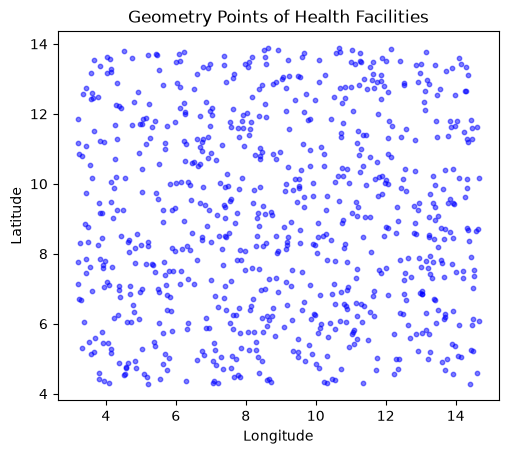

In [7]:
# visualize geometry points
gdf.plot(markersize=10, color="blue", alpha=0.5)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Geometry Points of Health Facilities")
plt.show()

## 02: Explore the Dataset Pt. 2

In [8]:
# buffers create a kind of a bubble between geometry points to better delineate them
buffers = gdf.copy()
buffers["geometry"] = gdf.buffer(0.10)

<Axes: >

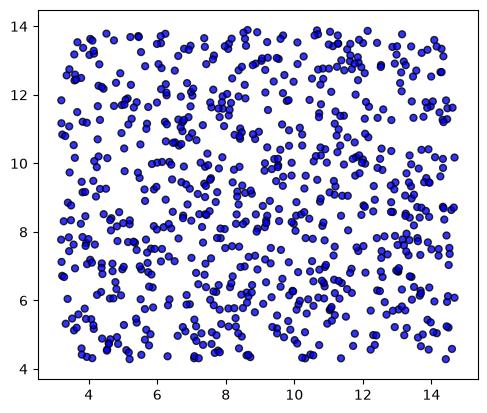

In [9]:
# visualize buffers
buffers.plot(color="blue", edgecolor="k", alpha=0.8)

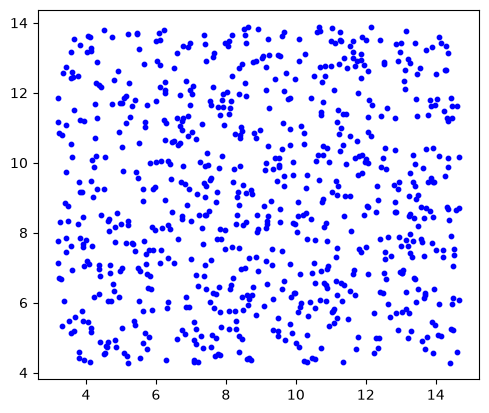

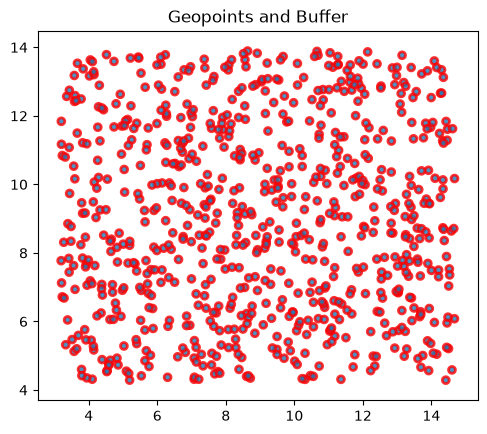

In [10]:
gdf.plot(color="blue", markersize=10, label="Geopoints")
buffers.plot(edgecolor="red", linewidth=2, label="Buffers", alpha=0.8)
plt.title("Geopoints and Buffer")
plt.show()

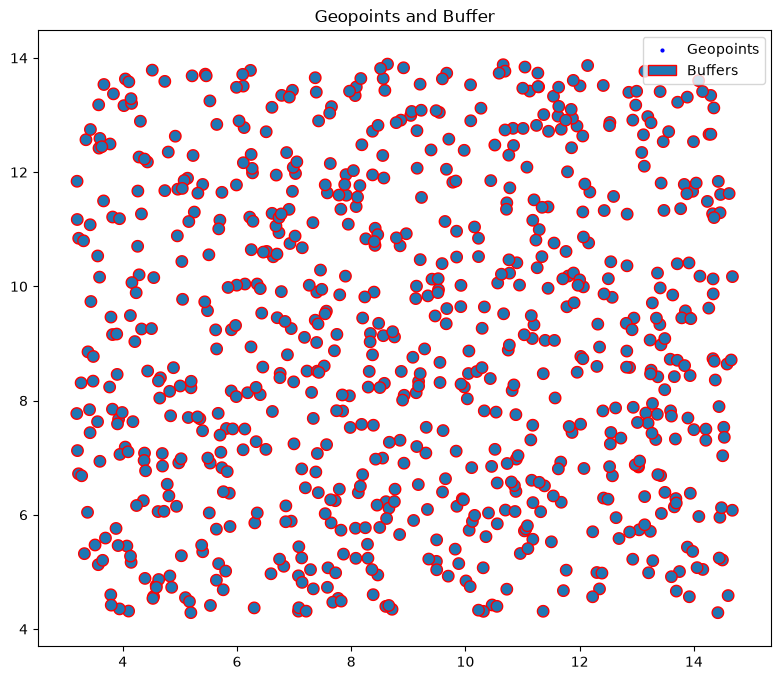

In [11]:
fig, ax = plt.subplots(figsize=(10, 8))
gdf.plot(ax=ax, color="blue", markersize=4, label="Geopoints")
buffers.plot(ax=ax, edgecolor="red", linewidth=1, label="Buffers")
plt.legend()
plt.title("Geopoints and Buffer")
plt.show()

## 03: Interactive Map Pt. 1

In [12]:
df_geo = pd.read_csv(input_folder_path+"demo_health_facilities_geo_data_NHC.csv")
df_geo

,Facility Type,Latitude,Longitude
0,Hospital,5.593051,3.697007
1,Hospital,10.017569,9.921846
2,Hospital,7.568808,11.178651
3,Hospital,11.574567,12.594135
4,Hospital,6.093634,9.334975
...,...,...,...
762,Pharmacy,11.844224,9.831699
763,Pharmacy,8.228317,8.502529
764,Pharmacy,8.162100,4.821424
765,Pharmacy,7.568452,8.388384


In [ ]:
# create a map
m = folium.Map(location=[df_geo["Latitude"].iloc[0], df_geo["Longitude"].iloc[0]])
for index, row in df_geo.iterrows():
    folium.Marker([row["Latitude"], row["Longitude"]], popup=row["Facility Type"]).add_to(m)
m.save(output_folder_path+"map.html")

In [ ]:
# I had to save the map to an .html file (and then open it in the integrated browser) because when running the code above...
# ... I was prompted the following message: "Make this Notebook Trusted to load map: File -> Trust Notebook"
# I tried to solve this issue using "Workspaces: Manage Workspace Trust" (via the Command Palette), however, it didn't work apparently

In [14]:
# create points with different colors for each type of facility
facility_color_mapping = {"Hospital": "red", "Primary Care Center": "blue", "Specialized Healthcare Center": "green", "Pharmacy": "purple"}

In [ ]:
m = folium.Map(location=[df_geo["Latitude"].iloc[0], df_geo["Longitude"].iloc[0]])
for index, row in df_geo.iterrows():
    facility_type = row["Facility Type"]
    if facility_type in facility_color_mapping:
        color = facility_color_mapping[facility_type]
    else:
        color = "gray"
    folium.Marker(location=[row["Latitude"], row["Longitude"]], popup=row["Facility Type"], icon=folium.Icon(color=color)).add_to(m)
m.save(output_folder_path+"map_colored.html")

## 04: Interactive Map Pt. 2

In [ ]:
# filter the map view for selected facilities
m = folium.Map(location=[df_geo["Latitude"].iloc[0], df_geo["Longitude"].iloc[0]])
facility_types_to_visualize = ["Hospital", "Pharmacy"]
filtered_df = df_geo[df_geo["Facility Type"].isin(facility_types_to_visualize)]

for index, row in filtered_df.iterrows():
    facility_type = row["Facility Type"]
    color = facility_color_mapping.get(facility_type, "gray")
    folium.Marker(location=[row["Latitude"], row["Longitude"]], popup=row["Facility Type"], icon=folium.Icon(color=color)).add_to(m)
m.save(output_folder_path+"map_filtered.html")

## 05: Interactive Map Pt. 3

In [ ]:
# create heatmaps and marker clusters
# heatmaps are used to observe density patterns and location trends

In [17]:
# create the "base" map
m = folium.Map(location=[df_geo["Latitude"].iloc[0], df_geo["Longitude"].iloc[0]])

In [ ]:
# define heatmap data and create the HeatMap object
heat_data = [[row["Latitude"], row["Longitude"]] for index, row in df_geo.iterrows()]
HeatMap(heat_data).add_to(m)
m.save(output_folder_path+"heatmap.html")

In [ ]:
# in the resulting heatmap, areas with a higher density of public health facilities have warmer colors, and vice versa

In [19]:
# (re)create the "base" map to create marker clusters
m = folium.Map(location=[df_geo["Latitude"].iloc[0], df_geo["Longitude"].iloc[0]])

In [20]:
# create a MarkerCluster object
marker_cluster = MarkerCluster()

In [ ]:
# add markers to the cluster
for index, row in df_geo.iterrows():
    marker = folium.Marker([row["Latitude"], row["Longitude"]], popup=row["Facility Type"])
    marker.add_to(marker_cluster)

marker_cluster.add_to(m)
m.save(output_folder_path+"marker_cluster.html")